$\chi$ plots

In [17]:
import argparse
import numpy as np
import matplotlib.pyplot as plt
import ast
import pandas as pd

In [18]:
import numpy as np
import matplotlib.pyplot as plt

path = "../SAVED_HERE/phi_chi_TEST1.csv"

# ---- Read file ----
with open(path, "r") as f:
    params = f.readline().strip()
    header = f.readline().strip().split(",")
    data = np.loadtxt(f, delimiter=",")

print("PARAMS:", params)
print("HEADER:", header)

# ---- Extract columns dynamically ----
t_arr = data[:, 0]
phi_arr = data[:, 1]
phi_prime_arr = data[:, 2]

# Find chi columns automatically
chi_indices = [i for i, name in enumerate(header) if name.startswith("chi_") and not name.startswith("chi_dot")]
chi_dot_indices = [i for i, name in enumerate(header) if name.startswith("chi_dot")]

chi_arr = data[:, chi_indices]
chi_dot_arr = data[:, chi_dot_indices]

print("Number of chi modes:", chi_arr.shape[1])


PARAMS: # params: {'kappa': 200, 'alpha': 1.5, 'b': 1.22, 'phi_sbp': 0.1, 'g': 0.1, 'k_min': 0, 'k_max': 100, 'n_k': 5, 'V0': 1e-12}
HEADER: ['t', 'phi', 'phi_prime', 'chi_0', 'chi_1', 'chi_2', 'chi_3', 'chi_4', 'chi_dot_0', 'chi_dot_1', 'chi_dot_2', 'chi_dot_3', 'chi_dot_4', 'a']
Number of chi modes: 5


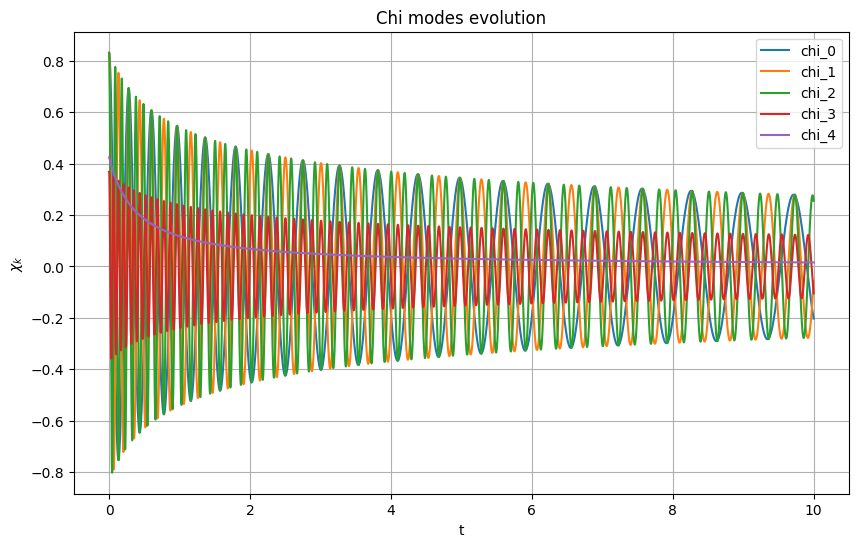

In [19]:
plt.figure(figsize=(10,6))

for i in range(chi_arr.shape[1]):
    plt.plot(t_arr, chi_arr[:, i], label=f"chi_{i}")

plt.xlabel("t")
plt.ylabel(r"$\chi_k$")
plt.title("Chi modes evolution")
plt.yscale("linear")   # change to "log" if needed
plt.legend()
plt.grid()
plt.show()


In [20]:
import numpy as np
import matplotlib.pyplot as plt

path = "../SAVED_HERE/phi_chi_TEST1.csv"

# ---------- Load ----------
with open(path, "r") as f:
    params_line = f.readline().strip()
    header = f.readline().strip().split(",")
    data = np.loadtxt(f, delimiter=",")

print("PARAMS:", params_line)
print("Ncols:", data.shape[1])
print("HEADER:", header)

# Column indices
col = {name: i for i, name in enumerate(header)}

t = data[:, col["t"]] if "t" in col else data[:, 0]
phi = data[:, col["phi"]]
phi_dot = data[:, col["phi_prime"]] if "phi_prime" in col else data[:, col.get("phi_dot", 2)]

# a is optional in your header, but you said you save it
a = data[:, col["a"]] if "a" in col else np.ones_like(t)

# Gather chi and chi_dot columns (ordered by index in the name)
def sorted_mode_cols(prefix):
    pairs = []
    for name, idx in col.items():
        if name.startswith(prefix):
            # extract trailing integer, e.g. "chi_12" -> 12
            try:
                mode = int(name.split("_")[-1])
                pairs.append((mode, idx))
            except ValueError:
                pass
    pairs.sort(key=lambda x: x[0])
    modes = [m for m, _ in pairs]
    idxs = [i for _, i in pairs]
    return np.array(modes, dtype=int), idxs

modes_chi, chi_idxs = sorted_mode_cols("chi_")
modes_chid, chid_idxs = sorted_mode_cols("chi_dot_")

chi_raw = data[:, chi_idxs]              # shape (nt, ncols_chi)
chi_dot_raw = data[:, chid_idxs]         # shape (nt, ncols_chidot)

# ---------- Decide if chi is real or (Re,Im) packed ----------
# Convention here:
#   If you used Re/Im split, you likely stored 2*n_k chi columns:
#       chi_0..chi_{n_k-1}, chi_{n_k}..chi_{2n_k-1}  (or similar)
#   If your header explicitly contains 'chi_re_' / 'chi_im_' you can adapt.
#
# We'll infer "packed" if number of chi columns equals number of chi_dot columns
# and is even, AND modes run 0..(2n_k-1).
packed_complex = False
nchi = chi_raw.shape[1]
nchid = chi_dot_raw.shape[1]

if nchi == nchid and nchi % 2 == 0:
    # check if modes look like 0..nchi-1
    if np.array_equal(modes_chi, np.arange(nchi)) and np.array_equal(modes_chid, np.arange(nchid)):
        packed_complex = True

if packed_complex:
    n_k = nchi // 2
    chi_re = chi_raw[:, :n_k]
    chi_im = chi_raw[:, n_k:]
    chi_dot_re = chi_dot_raw[:, :n_k]
    chi_dot_im = chi_dot_raw[:, n_k:]

    chi_abs2 = chi_re**2 + chi_im**2
    chi_dot_abs2 = chi_dot_re**2 + chi_dot_im**2
else:
    # purely real saved
    n_k = nchi
    chi_re = chi_raw
    chi_im = np.zeros_like(chi_re)
    chi_dot_re = chi_dot_raw
    chi_dot_im = np.zeros_like(chi_dot_re)

    chi_abs2 = chi_re**2
    chi_dot_abs2 = chi_dot_re**2

print("Detected n_k =", n_k, "| packed_complex =", packed_complex)

# ---------- Your model params (edit if needed) ----------
# We need g, phi_sbp, and k-array to compute Omega_k(t).
# If you saved k somewhere, load it; otherwise we can regenerate logspace bounds.
# For now: set these explicitly or parse params_line if it's JSON-like.
g = None
phi_sbp = None

# Try a very light parse for params like "... 'g': 5e-4, 'phi_sbp': 1.23 ..."
# If parsing fails, just set g and phi_sbp by hand below.
import re
def grab_float(key, s):
    m = re.search(rf"{key}\s*[:=]\s*([-+eE0-9\.]+)", s)
    return float(m.group(1)) if m else None

g = grab_float("g", params_line) or g
phi_sbp = grab_float("phi_sbp", params_line) or phi_sbp

# >>> IMPORTANT: if these printed as None, set them manually:
# g = 5.0e-4
# phi_sbp = <your value>

print("Parsed g =", g, "phi_sbp =", phi_sbp)

# if g is None or phi_sbp is None:
#     raise ValueError("Set g and phi_sbp (couldn't parse them from the params line).")

# ---------- k-modes ----------
# Best: read k from file. If not saved, regenerate using your same logic.
# This regeneration needs H(t) and phi(t) etc; you used k fixed at t0.
# We'll regenerate using your original IR/UV prescription at the initial time index 0.

# You also need V0, b, kappa if you want H from Friedmann in your form.
V0 = grab_float("V0", params_line)
b = grab_float("b", params_line)
kappa = grab_float("kappa", params_line)

# If not parsable, set manually:
V0 = 1e-12
b = 1.22
kappa = 200

if V0 is None or b is None or kappa is None:
    raise ValueError("Set V0, b, kappa (couldn't parse them from the params line).")

def V_func(phi, V0, b, kappa):
    return V0 * np.exp(-kappa * np.exp(phi / b))

def compute_H(phi, phi_prime, V0, b, kappa):
    denom = 3.0 - 0.5 * phi_prime**2
    return np.sqrt(V_func(phi, V0, b, kappa) / denom)

# infer phi_prime from your saved column name "phi_prime" (actually phi_dot in your run)
# If your RHS truly saved phi_dot, then phi_prime here is misnamed.
# We need phi_prime (dphi/dN) to use your compute_H formula.
# If you don't have phi_prime, you must compute H from something else.
#
# QUICK FIX: if what you saved is phi_prime = phi_dot, then your compute_H is not applicable.
# In that case, you'll need H saved in the CSV, or compute H from energy density using phi_dot.
#
# Let's detect this: if values look order ~0.4 and phi ~ -7, that's likely phi_dot? Hard to know.
# We'll assume you actually saved phi_prime (dphi/dN). If not, tell me and I'll adjust.

phi_prime = phi_dot  # rename for formula

H0 = compute_H(phi[0], phi_prime[0], V0, b, kappa)

ir_factor = 0.1
uv_factor = 5.0
p_min = ir_factor * H0
m_eff0 = g * abs(phi[0] - phi_sbp)
p_max = uv_factor * max(m_eff0, H0)

k_min = a[0] * p_min
k_max = a[0] * p_max
k = np.logspace(np.log10(k_min), np.log10(k_max), n_k)

# ---------- Omega_k(t) in cosmic-time chi equation ----------
# omega_k^2 = (k^2/a^2) + g^2 (phi - phi_sbp)^2
omega2 = (k[None, :]**2) / (a[:, None]**2) + (g**2) * (phi[:, None] - phi_sbp)**2
omega = np.sqrt(omega2)

# If you want the "conformal-vacuum" Omega (for X=a*chi or a^{3/2}chi etc),
# you'd need H, Hdot, etc from your background; for n_k(t) this "omega" is common choice.
# We'll use Omega=omega for occupation number estimate.

Omega = omega

# ---------- Quantities ----------
chi2 = chi_abs2
a3_chi2 = (a[:, None]**3) * chi2

# occupation number:
# n_k = (|chi_dot|^2 + Omega^2 |chi|^2) / (2 Omega) - 1/2
n_k_arr = (chi_dot_abs2 + (Omega**2) * chi2) / (2.0 * Omega) - 0.5

# ---------- Plots ----------
# 1) |chi_k|^2
plt.figure(figsize=(10, 6))
for i in range(n_k):
    plt.plot(t, chi2[:, i], label=f"k{i}")
plt.xlabel("t")
plt.ylabel(r"$|\chi_k|^2$")
plt.title(r"$|\chi_k|^2$ vs $t$")
plt.yscale("log")
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.show()

# 2) a^3 |chi_k|^2
plt.figure(figsize=(10, 6))
for i in range(n_k):
    plt.plot(t, a3_chi2[:, i], label=f"k{i}")
plt.xlabel("t")
plt.ylabel(r"$a^3 |\chi_k|^2$")
plt.title(r"$a^3 |\chi_k|^2$ vs $t$")
plt.yscale("log")
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.show()

# 3) occupation number n_k(t)
plt.figure(figsize=(10, 6))
for i in range(n_k):
    plt.plot(t, n_k_arr[:, i], label=f"k{i}")
plt.xlabel("t")
plt.ylabel(r"$n_k$")
plt.title(r"Occupation number $n_k(t)$")
plt.yscale("log")
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.show()


PARAMS: # params: {'kappa': 200, 'alpha': 1.5, 'b': 1.22, 'phi_sbp': 0.1, 'g': 0.1, 'k_min': 0, 'k_max': 100, 'n_k': 5, 'V0': 1e-12}
Ncols: 14
HEADER: ['t', 'phi', 'phi_prime', 'chi_0', 'chi_1', 'chi_2', 'chi_3', 'chi_4', 'chi_dot_0', 'chi_dot_1', 'chi_dot_2', 'chi_dot_3', 'chi_dot_4', 'a']
Detected n_k = 10 | packed_complex = False
Parsed g = None phi_sbp = None


TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'